# Notebook 02 — Synthetic 3-class KG experiments

Generates a synthetic clinic KG (Patient / Hospital / Therapy) with cross-class causality, writes it to `kgs/ttls/synthetic_clinic.ttl`, round-trips it through the ontology parser, and compares **constrained vs. unconstrained** discovery against a known ground-truth ontological causal graph.

Headline expectation: constrained ≥ unconstrained on precision and SHD; topological-validity = 1.0 for constrained, < 1.0 for unconstrained.

In [1]:
import os, sys

def _find_root():
    p = os.getcwd()
    for _ in range(8):
        if os.path.isdir(os.path.join(p, 'causalway')) and os.path.isdir(os.path.join(p, 'algs')):
            return p
        p = os.path.dirname(p)
    raise RuntimeError('project root not found')

PROJECT_ROOT = _find_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('PROJECT_ROOT =', PROJECT_ROOT)

PROJECT_ROOT = /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api


In [2]:
from runners.run_synthetic import build_synthetic_context, SYNTHETIC_TTL
from runners.run_kg_discovery import run_algorithm
from causalway.result import OntologicalCausalGraph
from causalway.synthetic import GROUND_TRUTH_EDGES

ctx, truth_adj = build_synthetic_context()
print('TTL written to', SYNTHETIC_TTL)
print('ground-truth edges:', len(GROUND_TRUTH_EDGES))
for c, e in GROUND_TRUTH_EDGES:
    print('  ', c, '->', e)

2026-09-23 09:38:41,243 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/backend/__init__.py[line:36] - INFO: You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).


2026-09-23 09:38:41,394 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/algorithms/__init__.py[line:36] - INFO: You are using ``pytorch`` as the backend.


/Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


Dropped constant columns: ['Patient.receives', 'Patient.treatedAt']
TTL written to /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/kgs/ttls/synthetic_clinic.ttl
ground-truth edges: 11
   Patient.age -> Patient.tumorStage
   Patient.smoking -> Patient.tumorStage
   Patient.geneticRisk -> Patient.tumorStage
   Patient.tumorStage -> Patient.survival
   Hospital.region -> Hospital.airPollution
   Hospital.airPollution -> Patient.tumorStage
   Hospital.careQuality -> Patient.survival
   Patient.tumorStage -> Therapy.dosage
   Therapy.drugClass -> Therapy.toxicity
   Therapy.dosage -> Therapy.toxicity
   Therapy.toxicity -> Patient.survival


In [3]:
print('schema summary:', ctx.schema.summary())
print('nodes (kept):', ctx.column_names)
print('dropped (constant object-property nodes):', ctx.dropped_columns)
print('constraint stats:', ctx.constraint_kept.stats())
print('multiplicity:', ctx.mat.multiplicity)
print('flat-join rows:', len(ctx.discrete_df), '| columns:', len(ctx.discrete_df.columns))

schema summary: {'n_classes': 3, 'n_object_properties': 2, 'n_object_domain_range': 2, 'n_data_properties': 11, 'n_data_domain_range': 11, 'n_inferred': 0}
nodes (kept): ['Hospital.airPollution', 'Hospital.careQuality', 'Hospital.region', 'Patient.age', 'Patient.geneticRisk', 'Patient.smoking', 'Patient.survival', 'Patient.tumorStage', 'Therapy.dosage', 'Therapy.drugClass', 'Therapy.toxicity']
dropped (constant object-property nodes): ['Patient.receives', 'Patient.treatedAt']
constraint stats: {'n_nodes': 11, 'n_allowed': 92, 'n_forbidden': 18, 'pruning_rate': 0.16363636363636364}
multiplicity: {'Hospital': 62.0, 'Patient': 2.48, 'Therapy': 1.0}
flat-join rows: 1240 | columns: 11


## Constrained vs. unconstrained

The flat join repeats a `Patient` row once per therapy, so the i.i.d. assumption of every algorithm is (knowingly) violated — a documented limitation, not silently papered over. Cross-class `Hospital ↔ Therapy` edges are the ones Assumption 1 prunes.

In [4]:
methods = ['GES', 'GES-M-B-HL', 'GES-M-B', 'PC', 'NOTEARS', 'DAGMA'] #, 'LiNGAM', 'DAG-GNN']
truth_ocg = OntologicalCausalGraph(nodes=ctx.nodes_kept, adj=truth_adj)

rows = []
adjs = {}
for m in methods:
    for constrained in (True, False):
        adj = run_algorithm(m, ctx, constrained=constrained)
        adjs[(m, constrained)] = adj
        ocg = OntologicalCausalGraph.from_discovery(adj, ctx.constraint_kept)
        met = ocg.metrics(truth_ocg)
        met['topological_validity'] = ocg.topological_validity(ctx.constraint_kept)
        met['method'] = m
        met['constrained'] = constrained
        rows.append(met)

table = pd.DataFrame(rows).set_index(['method', 'constrained'])
table[['shd', 'precision', 'recall', 'f1', 'topological_validity', 'n_edges']].round(3)

  0%|          | 0/1000000 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

2026-09-23 09:39:05,495 - /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/algs/constrained/notears.py[line:105] - INFO: [start]: n=1240, d=11, iter_=100, h_=1e-08, rho_=1e+16


2026-09-23 09:39:05,509 - /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/algs/constrained/notears.py[line:116] - INFO: [iter 0] h=2.067e-01, loss=3.634, rho=1.0e+00


2026-09-23 09:39:05,520 - /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/algs/constrained/notears.py[line:116] - INFO: [iter 1] h=1.527e-01, loss=2.507, rho=1.0e+00


...

2026-09-23 09:39:07,463 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/algorithms/gradient/notears/linear.py[line:206] - INFO: [iter 11] h=2.917e-09, loss=2.821, rho=1.0e+13


2026-09-23 09:39:07,466 - /Users/jason/miniconda3/envs/rdfenv/lib/python3.11/site-packages/castle/algorithms/gradient/notears/linear.py[line:222] - INFO: FINISHED


  0%|          | 0/180000.0 [00:00<?, ?it/s]

  0%|          | 0/180000.0 [00:00<?, ?it/s]

shd  precision  recall     f1  topological_validity  \
method     constrained                                                        
GES        True           5      0.714   0.909  0.800                   1.0   
           False          5      0.714   0.909  0.800                   1.0   
GES-M-B-HL True           7      0.667   0.727  0.696                   1.0   
           False          7      0.667   0.727  0.696                   1.0   
GES-M-B    True           5      0.750   0.818  0.783                   1.0   
           False          5      0.750   0.818  0.783                   1.0   
PC         True          10      0.533   0.727  0.615                   1.0   
           False         10      0.533   0.727  0.615                   1.0   
NOTEARS    True          11      0.500   0.364  0.421                   1.0   
           False         10      0.556   0.455  0.500                   1.0   
DAGMA      True          12      0.462   0.545  0.500                   1.0   
           False         12      0.462   0.545  0.500                   1.0   

                        n_edges  
method     constrained           
GES        True              14  
           False             14  
GES-M-B-HL True              12  
           False             12  
GES-M-B    True              12  
           False             12  
PC         True              15  
           False             15  
NOTEARS    True               8  
           False              9  
DAGMA      True              13  
           False             13

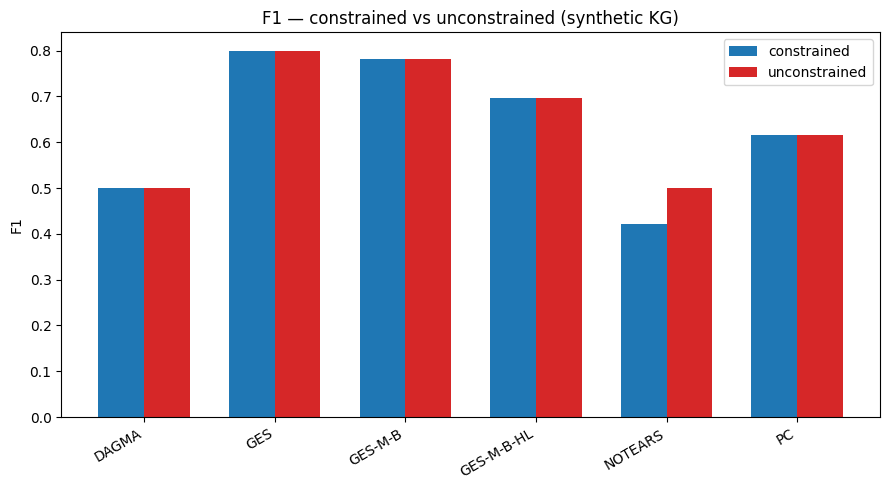

In [5]:
metric = 'f1'
disp = table[[metric]].reset_index()
pivot = disp.pivot(index='method', columns='constrained', values=metric)

x = np.arange(len(pivot))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, pivot[True], w, label='constrained', color='#1f77b4')
ax.bar(x + w/2, pivot[False], w, label='unconstrained', color='#d62728')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.set_ylabel(metric.upper())
ax.set_title(metric.upper() + ' — constrained vs unconstrained (synthetic KG)')
ax.legend()
fig.tight_layout()
plt.show()

In [6]:
from runners.run_kg_discovery import estimate_and_cache_priors

cache = os.path.join(PROJECT_ROOT, 'results', 'priors_synthetic.json')
priors, var_meta, pair_meta, domain = estimate_and_cache_priors(ctx, cache, llm_model='deepseek-v4-flash-vision-exp') #'deepseek-v4-flash')
if priors is None:
    print('LLM priors unavailable (check DEEPSEEK_KEY); skipping')
else:
    adj = run_algorithm('GES-M-B-HL', ctx, constrained=True,
                        priors=priors, var_meta=var_meta, pair_meta=pair_meta, domain=domain)
    ocg = OntologicalCausalGraph.from_discovery(adj, ctx.constraint_kept)
    print('GES-M-B-HL (LLM) metrics:', ocg.metrics(truth_ocg))

Loading cached priors from /Users/jason/Documents/Coding Projects.nosync/2026_Claude/CausalKG_api/results/priors_synthetic.json


  0%|          | 0/1000000 [00:00<?, ?it/s]

GES-M-B-HL (LLM) metrics: {'shd': 5, 'n_edges': 12, 'n_truth_edges': 11, 'precision': 0.75, 'recall': 0.8181818181818182, 'f1': 0.7826086956521738, 'skeleton_precision': 0.9166666666666666, 'skeleton_recall': 1.0, 'skeleton_f1': 0.9565217391304348}


## Ablations

In [7]:
from causalway.constraints import EdgeConstraint

schema, nodes = ctx.schema, ctx.nodes
keep = [i for i, n in enumerate(nodes) if n.name in ctx.discrete_df.columns]

for direction in ('both', 'forward'):
    c = EdgeConstraint.from_schema(schema, nodes, relation_direction=direction).subset(keep)
    print('relation_direction=' + direction.ljust(7), 'pruning_rate=', round(c.stats()['pruning_rate'], 3))

for hops in (1, 2):
    c = EdgeConstraint.from_schema(schema, nodes, max_hops=hops).subset(keep)
    print('max_hops=' + str(hops), 'pruning_rate=', round(c.stats()['pruning_rate'], 3))

relation_direction=both    pruning_rate= 0.164
relation_direction=forward pruning_rate= 0.436
max_hops=1 pruning_rate= 0.164
max_hops=2 pruning_rate= 0.0


In [8]:
# hard constraint vs soft prior vs post-hoc masking
n = len(ctx.column_names)
hard_adj = run_algorithm('GES', ctx, constrained=True)

soft_B = ctx.constraint_kept.soft_prior(eps=1e-4)
soft_adj = run_algorithm('GES-M-B', ctx, constrained=False,
                         priors={'M': soft_B.copy(), 'B': soft_B.copy()})

u_adj = run_algorithm('GES', ctx, constrained=False)
posthoc_adj = u_adj.copy()
for i in range(n):
    for j in range(n):
        if i != j and not ctx.constraint_kept.allowed[i, j]:
            posthoc_adj[i, j] = 0

for name, adj in [('hard', hard_adj), ('soft prior', soft_adj), ('post-hoc mask', posthoc_adj)]:
    ocg = OntologicalCausalGraph.from_discovery(adj, ctx.constraint_kept)
    print(name.ljust(14), 'validity=', round(ocg.topological_validity(ctx.constraint_kept), 3),
          '| F1=', round(ocg.metrics(truth_ocg)['f1'], 3))

hard           validity= 1.0 | F1= 0.8
soft prior     validity= 1.0 | F1= 0.783
post-hoc mask  validity= 1.0 | F1= 0.8


In [9]:
import tempfile

# Each sweep point gets its own scratch TTL. The default ttl_path is the shipped
# sample kgs/ttls/synthetic_clinic.ttl, which the web service and notebook 04 read.
for n_patients in (200, 500, 2000):
    sweep_ttl = os.path.join(tempfile.gettempdir(), f'synthetic_clinic_n{n_patients}.ttl')
    ctx_n, truth_n = build_synthetic_context(ttl_path=sweep_ttl, n_patients=n_patients)
    truth_n_ocg = OntologicalCausalGraph(nodes=ctx_n.nodes_kept, adj=truth_n)
    c = run_algorithm('GES', ctx_n, constrained=True)
    u = run_algorithm('GES', ctx_n, constrained=False)
    c_ocg = OntologicalCausalGraph.from_discovery(c, ctx_n.constraint_kept)
    u_ocg = OntologicalCausalGraph.from_discovery(u, ctx_n.constraint_kept)
    print('n=' + str(n_patients).ljust(4),
          'constrained F1=', round(c_ocg.metrics(truth_n_ocg)['f1'], 3),
          '| unconstrained F1=', round(u_ocg.metrics(truth_n_ocg)['f1'], 3))

Dropped constant columns: ['Patient.receives', 'Patient.treatedAt']


n=200  constrained F1= 0.583 | unconstrained F1= 0.583


Dropped constant columns: ['Patient.receives', 'Patient.treatedAt']


n=500  constrained F1= 0.8 | unconstrained F1= 0.8


Dropped constant columns: ['Patient.receives', 'Patient.treatedAt']


n=2000 constrained F1= 0.815 | unconstrained F1= 0.815


In [10]:
out_dir = os.path.join(PROJECT_ROOT, 'results', 'synthetic')
os.makedirs(out_dir, exist_ok=True)
best_adj = adjs[('GES', True)]
best_ocg = OntologicalCausalGraph.from_discovery(best_adj, ctx.constraint_kept)
best_ocg.to_turtle(os.path.join(out_dir, 'best_GES_constrained.ttl'))
print(best_ocg.to_dataframe())

   method                  cause                 effect cause_domain  \
0    None  Hospital.airPollution        Hospital.region     Hospital   
1    None  Hospital.airPollution     Patient.tumorStage     Hospital   
2    None   Hospital.careQuality        Hospital.region     Hospital   
3    None   Hospital.careQuality       Patient.survival     Hospital   
4    None        Hospital.region  Hospital.airPollution     Hospital   
5    None        Hospital.region   Hospital.careQuality     Hospital   
6    None    Patient.geneticRisk     Patient.tumorStage      Patient   
7    None        Patient.smoking     Patient.tumorStage      Patient   
8    None     Patient.tumorStage            Patient.age      Patient   
9    None     Patient.tumorStage       Patient.survival      Patient   
10   None     Patient.tumorStage         Therapy.dosage      Patient   
11   None         Therapy.dosage       Therapy.toxicity      Therapy   
12   None      Therapy.drugClass       Therapy.toxicity      The